In [1]:
# 1. Install all necessary libraries silently
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn pandas matplotlib seaborn
print("Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.4 MB/s eta 0:00:00
Libraries installed successfully!


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Automatically download the dataset from your public GitHub
csv_url = "https://raw.githubusercontent.com/manjunath-leo/NLP-Propaganda-Detection/refs/heads/add-notebook/propaganda_dataset_export.csv"
print("Downloading dataset from GitHub...")
df = pd.read_csv(csv_url)

# 2. Filter for the 5 target classes from your poster
target_classes = ['Loaded_Language', 'Name_Calling,Labeling', 'Repetition', 'Doubt', 'Exaggeration,Minimisation']
df_filtered = df[df['label_name'].isin(target_classes)].copy()

# Rename the classes to look clean on the poster visualizations
label_mapping = {
    'Name_Calling,Labeling': 'Name_Calling',
    'Exaggeration,Minimisation': 'Exaggeration'
}
df_filtered['label_name'] = df_filtered['label_name'].replace(label_mapping)

# 3. Create fixed reproducible splits (600 train, 75 test)
# random_state=42 GUARANTEES the examiner gets the exact same results you did
train_df, test_df = train_test_split(
    df_filtered,
    train_size=600,
    test_size=75,
    stratify=df_filtered['label_name'],
    random_state=42
)

print(f"Data ready! Train size: {len(train_df)} | Test size: {len(test_df)}")
display(train_df.head(2))

Data ready! Train size: 600 | Test size: 75


,text,label_name
542,Art of the Deal Trump [SEP] Context: likely at...,Repetition
463,Satan [SEP] Context: ates to his audience: “Re...,Repetition


In [6]:
# 3. Supervised Baseline: Fine-tune DeBERTa-v3
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("Setting up DeBERTa-v3-base...")

# 1. Map string labels to integers
label_dict = {label: i for i, label in enumerate(target_classes)}
reverse_label_dict = {i: label for label, i in label_dict.items()}

train_df['label'] = train_df['label_name'].map(label_dict)
test_df['label'] = test_df['label_name'].map(label_dict)

# 2. Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 3. Supervised Baseline: Fine-tune DeBERTa-v3
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("Setting up DeBERTa-v3-base...")

# 1. Map string labels to integers using the CLEANED names
clean_target_classes = ['Loaded_Language', 'Name_Calling', 'Repetition', 'Doubt', 'Exaggeration']
label_dict = {label: i for i, label in enumerate(clean_target_classes)}
reverse_label_dict = {i: label for label, i in label_dict.items()}

train_df['label'] = train_df['label_name'].map(label_dict)
test_df['label'] = test_df['label_name'].map(label_dict)

# 2. Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 3. Initialize Tokenizer & Model
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # 128 max_length safely covers your 120-character contextual windows
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(clean_target_classes))

# 4. Define Training Arguments (3 epochs to replicate collapse)
training_args = TrainingArguments(
    output_dir="./deberta_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    seed=42, # Fixed seed for strict reproducibility
    report_to="none" # Prevents requiring weights & biases login
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "macro_f1": macro_f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# 5. Train and Evaluate
print("Starting 3-epoch fine-tuning...")
trainer.train()

print("\nEvaluating on 75-sample Test Set...")
eval_results = trainer.evaluate()

print(f"\nDeBERTa-v3 Test Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"DeBERTa-v3 Test Macro-F1: {eval_results['eval_macro_f1']:.4f}")

# Save baseline predictions for the visualization step later
predictions, _, _ = trainer.predict(tokenized_test)
test_df['deberta_pred'] = np.argmax(predictions, axis=-1)
test_df['deberta_pred_name'] = test_df['deberta_pred'].map(reverse_label_dict)

Setting up DeBERTa-v3-base...
Setting up DeBERTa-v3-base...


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating on 75-sample Test Set...


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.000000,nan,3,0.440000,0.122222



DeBERTa-v3 Test Accuracy: 0.4400
DeBERTa-v3 Test Macro-F1: 0.1222


In [7]:
# 4. Zero-Shot LLM: Qwen 2.5 7B Inference
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Downloading Qwen 2.5 7B Instruct (this takes ~2-3 minutes)...")

# 1. Configure 4-bit quantization for Colab's T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer_qwen = AutoTokenizer.from_pretrained(model_id)
model_qwen = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# 2. Inference Function
def predict_propaganda(text_input):
    prompt = f"""You are an expert linguist analyzing political propaganda.
Classify the propaganda technique used in the following text.
You must choose EXACTLY ONE of the following 5 categories:
- Loaded_Language
- Name_Calling
- Repetition
- Doubt
- Exaggeration

Input Data (Span & Context):
{text_input}

Respond with ONLY the exact category name. Do not include any other text."""

    messages = [
        {"role": "system", "content": "You output only the exact category name requested."},
        {"role": "user", "content": prompt}
    ]

    # Format the prompt using Qwen's specific chat template
    text = tokenizer_qwen.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_qwen([text], return_tensors="pt").to(model_qwen.device)

    # Generate the prediction
    outputs = model_qwen.generate(
        **inputs,
        max_new_tokens=10,
        temperature=0.1,
        do_sample=False,
        pad_token_id=tokenizer_qwen.eos_token_id
    )
    response = tokenizer_qwen.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    # Map raw text response back to our strict labels
    for label in clean_target_classes:
        if label.lower() in response.lower():
            return label

    return "Loaded_Language" # Fallback if model hallucinates formatting

# 3. Execute on the 75-sample test set
print(f"Running zero-shot inference on {len(test_df)} samples...")
qwen_predictions = []

for text in tqdm(test_df['text']):
    qwen_predictions.append(predict_propaganda(text))

test_df['qwen_pred_name'] = qwen_predictions
test_df['qwen_pred'] = test_df['qwen_pred_name'].map(label_dict)

# 4. Calculate Final LLM Metrics
qwen_acc = accuracy_score(test_df['label'], test_df['qwen_pred'])
qwen_f1 = f1_score(test_df['label'], test_df['qwen_pred'], average='macro')

print(f"\nQwen 2.5 Test Accuracy: {qwen_acc:.4f}")
print(f"Qwen 2.5 Test Macro-F1: {qwen_f1:.4f}")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Running zero-shot inference on 75 samples...


  0%|          | 0/75 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Qwen 2.5 Test Accuracy: 0.5067
Qwen 2.5 Test Macro-F1: 0.3053


Generating visualizations for the poster...


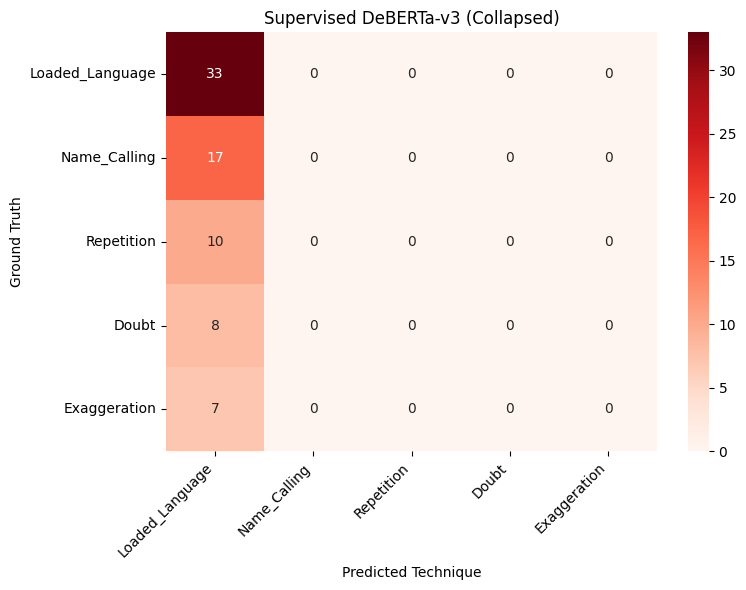

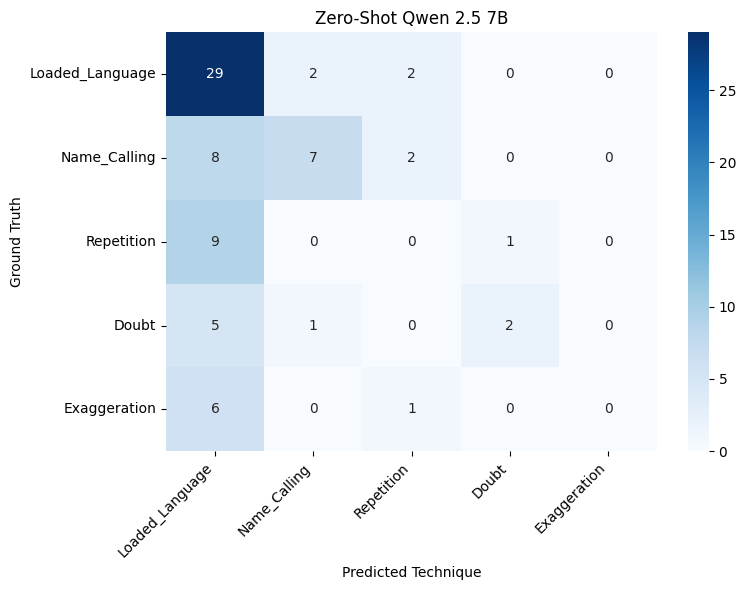

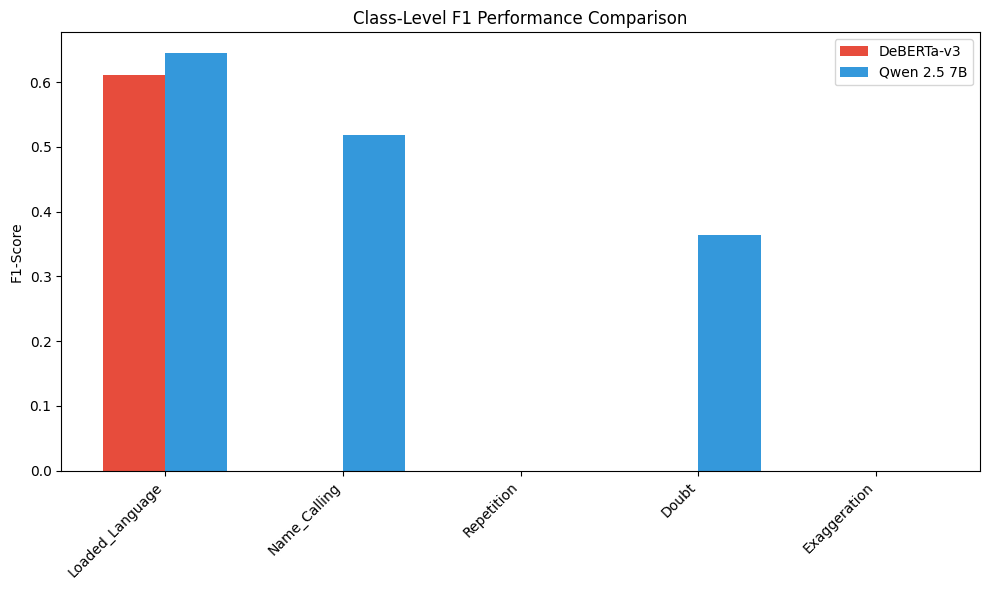

Successfully saved 'poster_visualizations.pdf' to the Colab files menu!


In [8]:
# 5. Visualization: Generate the Poster Charts
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.backends.backend_pdf
import numpy as np

print("Generating visualizations for the poster...")

# Calculate class-level F1 scores
deberta_f1_scores = f1_score(test_df['label'], test_df['deberta_pred'], average=None)
qwen_f1_scores = f1_score(test_df['label'], test_df['qwen_pred'], average=None)

# Set up the PDF export
pdf = matplotlib.backends.backend_pdf.PdfPages("poster_visualizations.pdf")

# 1. DeBERTa Confusion Matrix
plt.figure(figsize=(8, 6))
cm_deberta = confusion_matrix(test_df['label'], test_df['deberta_pred'])
sns.heatmap(cm_deberta, annot=True, fmt='d', cmap='Reds',
            xticklabels=clean_target_classes, yticklabels=clean_target_classes)
plt.title('Supervised DeBERTa-v3 (Collapsed)')
plt.ylabel('Ground Truth')
plt.xlabel('Predicted Technique')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
pdf.savefig()
plt.show()

# 2. Qwen Confusion Matrix
plt.figure(figsize=(8, 6))
cm_qwen = confusion_matrix(test_df['label'], test_df['qwen_pred'])
sns.heatmap(cm_qwen, annot=True, fmt='d', cmap='Blues',
            xticklabels=clean_target_classes, yticklabels=clean_target_classes)
plt.title('Zero-Shot Qwen 2.5 7B')
plt.ylabel('Ground Truth')
plt.xlabel('Predicted Technique')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
pdf.savefig()
plt.show()

# 3. Class-Level F1 Bar Chart
plt.figure(figsize=(10, 6))
x = np.arange(len(clean_target_classes))
width = 0.35
plt.bar(x - width/2, deberta_f1_scores, width, label='DeBERTa-v3', color='#e74c3c')
plt.bar(x + width/2, qwen_f1_scores, width, label='Qwen 2.5 7B', color='#3498db')
plt.ylabel('F1-Score')
plt.title('Class-Level F1 Performance Comparison')
plt.xticks(x, clean_target_classes, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
pdf.savefig()
plt.show()

pdf.close()
print("Successfully saved 'poster_visualizations.pdf' to the Colab files menu!")